# 01 — Exploratory Data Analysis & Data Cleaning
**Financial Operations Analytics — IBM Telco Customer Churn (California)**

This notebook loads the raw dataset, fixes data types, handles missing values and
outliers, profiles the key churn / tenure / revenue distributions, builds a
correlation heatmap, and documents every field in a **data dictionary**. The cleaned
output (`data/processed/telco_clean.csv`) is the single source of truth for notebooks
02–05.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the repo root importable and resolve paths regardless of CWD.
ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "dashboard"} else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.viz import set_style, save_fig
set_style()

RAW = ROOT / "data" / "raw" / "telco_financial_raw.csv"
PROC = ROOT / "data" / "processed" / "telco_clean.csv"
pd.set_option("display.max_columns", 50)
print("pandas", pd.__version__)

pandas 2.3.3


In [2]:
# Generate the raw file on the fly if it is missing (fully reproducible).
if not RAW.exists():
    from src.data_generation import main as gen
    gen()

df = pd.read_csv(RAW)
print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Raw shape: 7,043 rows x 39 columns


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,MonthlyProfit,CostToServe,MarketingSpend,Discount,Region,SignupMonth
0,8813-FVEQT,1,United States,California,Sacramento,95814,"38.6807, -121.5338",38.6807,-121.5338,Female,0,No,No,12,Yes,No,DSL,Yes,No,Yes,Yes,Yes,No,Month-to-month,No,Credit card (automatic),65.62,767.51,Yes,1,34,2879,Competitor had better devices,12.78,35.41,293.88,0.079,North California,2020-02-01
1,3367-LWVXQ,1,United States,California,San Diego,92101,"32.718, -117.2095",32.7180,-117.2095,Female,1,Yes,No,22,No,No phone service,Fiber optic,No,No,No,No,No,Yes,One year,Yes,Electronic check,66.72,1485.93,Yes,1,40,3001,Competitor made better offer,16.90,30.90,282.79,0.107,South California,2019-04-01
2,8983-KPRZJ,1,United States,California,Modesto,95354,"37.6423, -120.9105",37.6423,-120.9105,Female,0,No,No,63,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,No,Month-to-month,Yes,Electronic check,87.02,5461.76,Yes,1,52,4595,Attitude of support person,33.74,45.37,160.67,0.014,Central California,2015-11-01
3,8872-NCRZL,1,United States,California,Fresno,93701,"36.7191, -119.7814",36.7191,-119.7814,Female,0,No,No,48,Yes,No,Fiber optic,No,Yes,No,Yes,No,No,Month-to-month,No,Electronic check,77.33,3689.5,Yes,1,52,4662,Competitor made better offer,31.45,31.70,321.72,0.010,Central California,2017-02-01
4,5938-YXKTQ,1,United States,California,Fresno,93701,"36.7931, -119.7308",36.7931,-119.7308,Female,0,Yes,No,7,Yes,Yes,DSL,No,No,No,No,No,No,Two year,Yes,Electronic check,50.51,349.21,No,0,25,3535,NaN,11.85,19.32,227.67,0.195,Central California,2020-07-01


## 1. Structure & dtypes

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   int64  
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
# Total Charges arrives as text because brand-new (tenure 0) customers have a
# blank value in the IBM export. Convert to numeric and quantify the blanks.
blank_tc = pd.to_numeric(df["Total Charges"], errors="coerce").isna().sum()
print(f"Blank / non-numeric 'Total Charges': {blank_tc}")
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

Blank / non-numeric 'Total Charges': 18


## 2. Missing values

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
# 'Churn Reason' is missing by design for non-churned customers -> fill explicitly.
df["Churn Reason"] = df["Churn Reason"].fillna("Not Churned")
# Total Charges blanks correspond to tenure 0 -> first month not yet billed = 0.
df.loc[df["Total Charges"].isna(), "Total Charges"] = 0.0
print("Remaining nulls:", int(df.isna().sum().sum()))

Churn Reason     4883
Total Charges      18
dtype: int64
Remaining nulls: 0


In [6]:
# Duplicate customer IDs / rows
print("Duplicate CustomerIDs:", int(df["CustomerID"].duplicated().sum()))
print("Fully duplicated rows :", int(df.duplicated().sum()))

Duplicate CustomerIDs: 0
Fully duplicated rows : 0


## 3. Outlier handling (IQR capping)
Continuous financial fields are winsorised at the 1.5×IQR fences so a handful of
extreme values cannot distort downstream models. We cap (not drop) to preserve the
7,043-row panel.

In [7]:
def iqr_caps(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

num_cols = ["Monthly Charges", "Total Charges", "MonthlyProfit",
            "CostToServe", "MarketingSpend"]
caps = {}
for c in num_cols:
    lo, hi = iqr_caps(df[c])
    n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
    df[c] = df[c].clip(lo, hi)
    caps[c] = (round(lo, 2), round(hi, 2), n_out)
pd.DataFrame(caps, index=["lower_cap", "upper_cap", "n_capped"]).T

,lower_cap,upper_cap,n_capped
Monthly Charges,7.17,119.94,0.0
Total Charges,-4291.00,8803.66,0.0
MonthlyProfit,-24.79,51.95,0.0
CostToServe,1.01,55.37,1.0
MarketingSpend,-54.91,639.44,0.0


## 4. Churn distribution

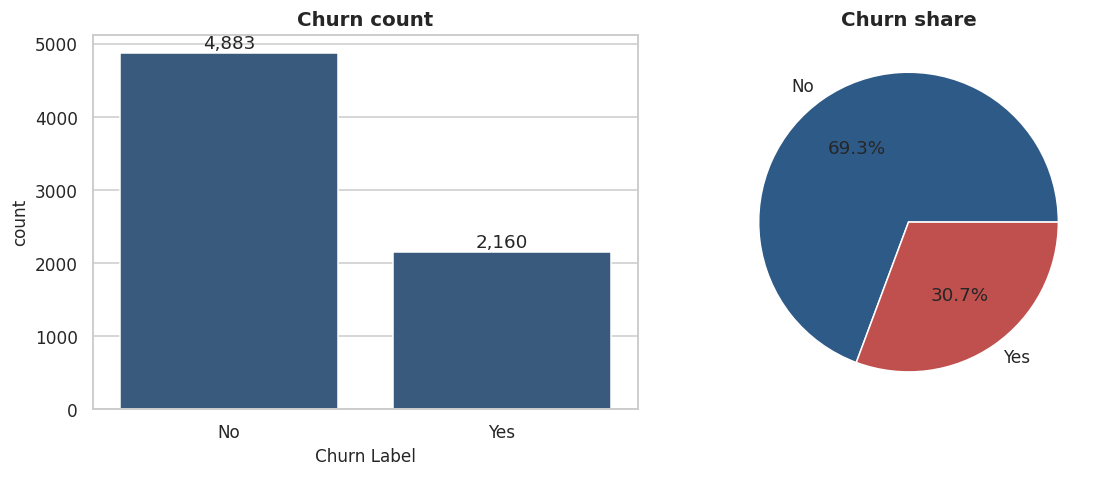

Overall churn rate: 30.7%


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
order = ["No", "Yes"]
sns.countplot(data=df, x="Churn Label", order=order, ax=ax[0])
ax[0].set_title("Churn count")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                   ha="center", va="bottom")
df["Churn Label"].value_counts(normalize=True).reindex(order).plot.pie(
    autopct="%1.1f%%", ax=ax[1], ylabel="", colors=["#2E5A88", "#C0504D"])
ax[1].set_title("Churn share")
plt.tight_layout(); save_fig(fig, "01_churn_distribution"); plt.show()
print(f"Overall churn rate: {df['Churn Value'].mean():.1%}")

## 5. Tenure distribution

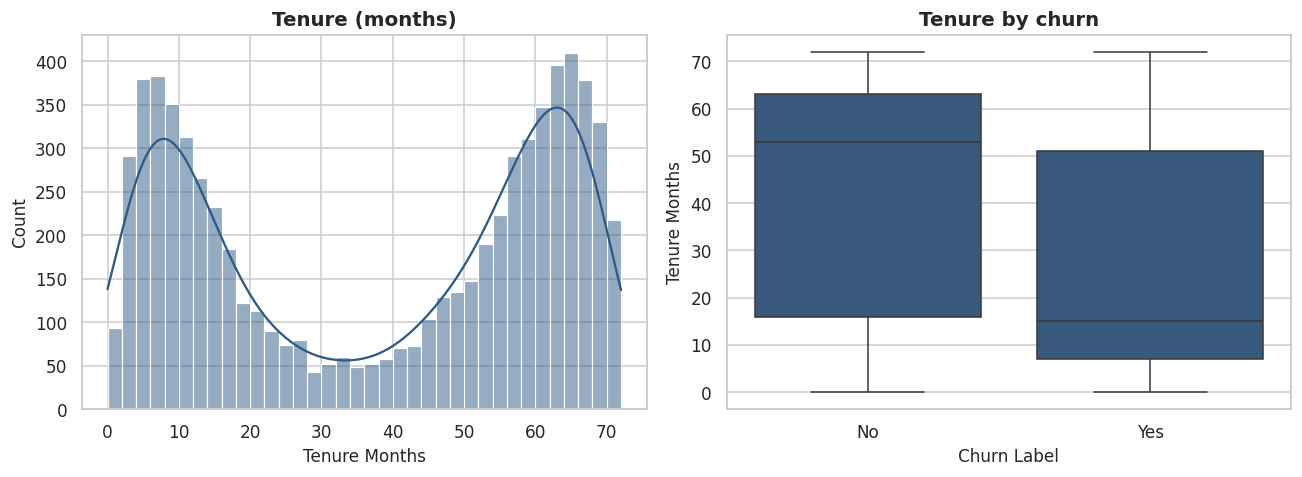

Churn Label
No     53.0
Yes    15.0
Name: Tenure Months, dtype: float64


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Tenure Months"], bins=36, kde=True, ax=ax[0], color="#2E5A88")
ax[0].set_title("Tenure (months)")
sns.boxplot(data=df, x="Churn Label", y="Tenure Months", order=order, ax=ax[1])
ax[1].set_title("Tenure by churn")
plt.tight_layout(); save_fig(fig, "01_tenure_distribution"); plt.show()
print(df.groupby("Churn Label")["Tenure Months"].median())

## 6. Revenue & profit distributions

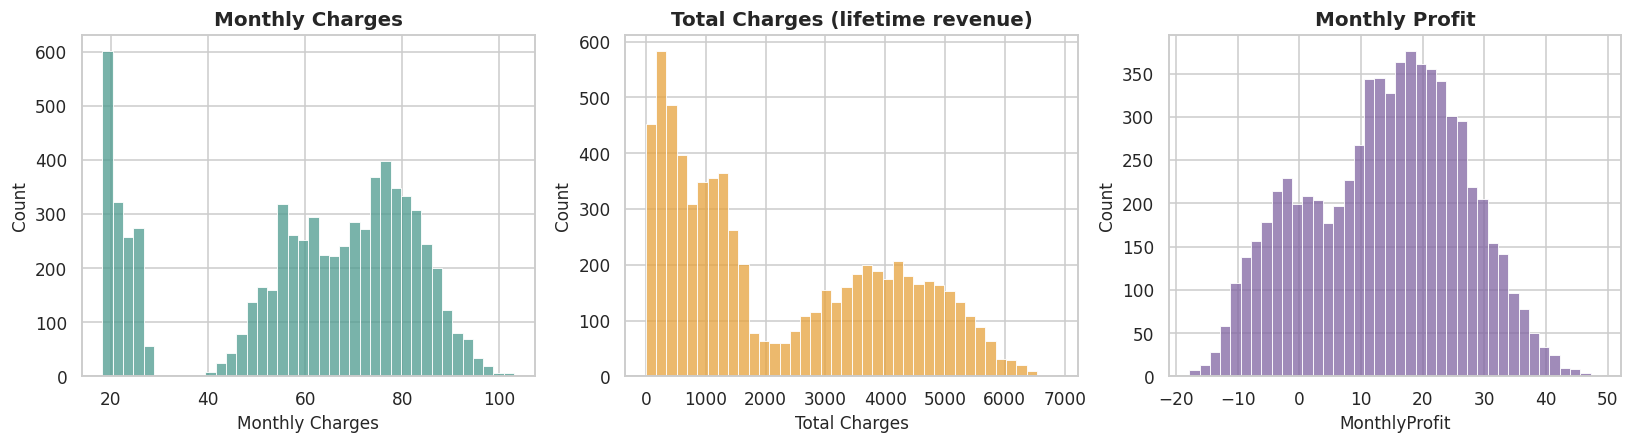

,Monthly Charges,Total Charges,MonthlyProfit
count,7043.00,7043.00,7043.00
mean,59.88,2258.05,13.79
std,22.80,1808.95,12.64
min,18.25,0.00,-17.87
25%,49.46,619.50,3.99
50%,65.23,1522.32,15.01
75%,77.65,3893.16,23.18
max,103.03,6878.56,48.88


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
sns.histplot(df["Monthly Charges"], bins=40, ax=ax[0], color="#4C9A8E")
ax[0].set_title("Monthly Charges")
sns.histplot(df["Total Charges"], bins=40, ax=ax[1], color="#E6A23C")
ax[1].set_title("Total Charges (lifetime revenue)")
sns.histplot(df["MonthlyProfit"], bins=40, ax=ax[2], color="#8064A2")
ax[2].set_title("Monthly Profit")
plt.tight_layout(); save_fig(fig, "01_revenue_distributions"); plt.show()
df[["Monthly Charges", "Total Charges", "MonthlyProfit"]].describe().round(2)

## 7. Churn by contract & region

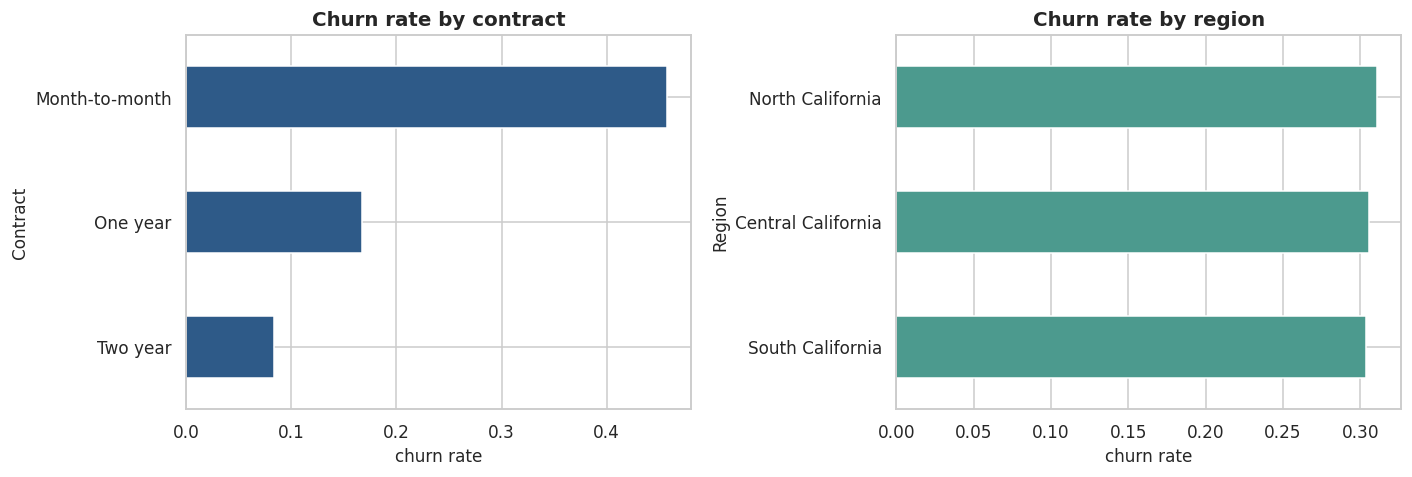

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
(df.groupby("Contract")["Churn Value"].mean().sort_values()
   .plot.barh(ax=ax[0], color="#2E5A88"))
ax[0].set_title("Churn rate by contract"); ax[0].set_xlabel("churn rate")
(df.groupby("Region")["Churn Value"].mean().sort_values()
   .plot.barh(ax=ax[1], color="#4C9A8E"))
ax[1].set_title("Churn rate by region"); ax[1].set_xlabel("churn rate")
plt.tight_layout(); save_fig(fig, "01_churn_by_segment"); plt.show()

## 8. Correlation heatmap

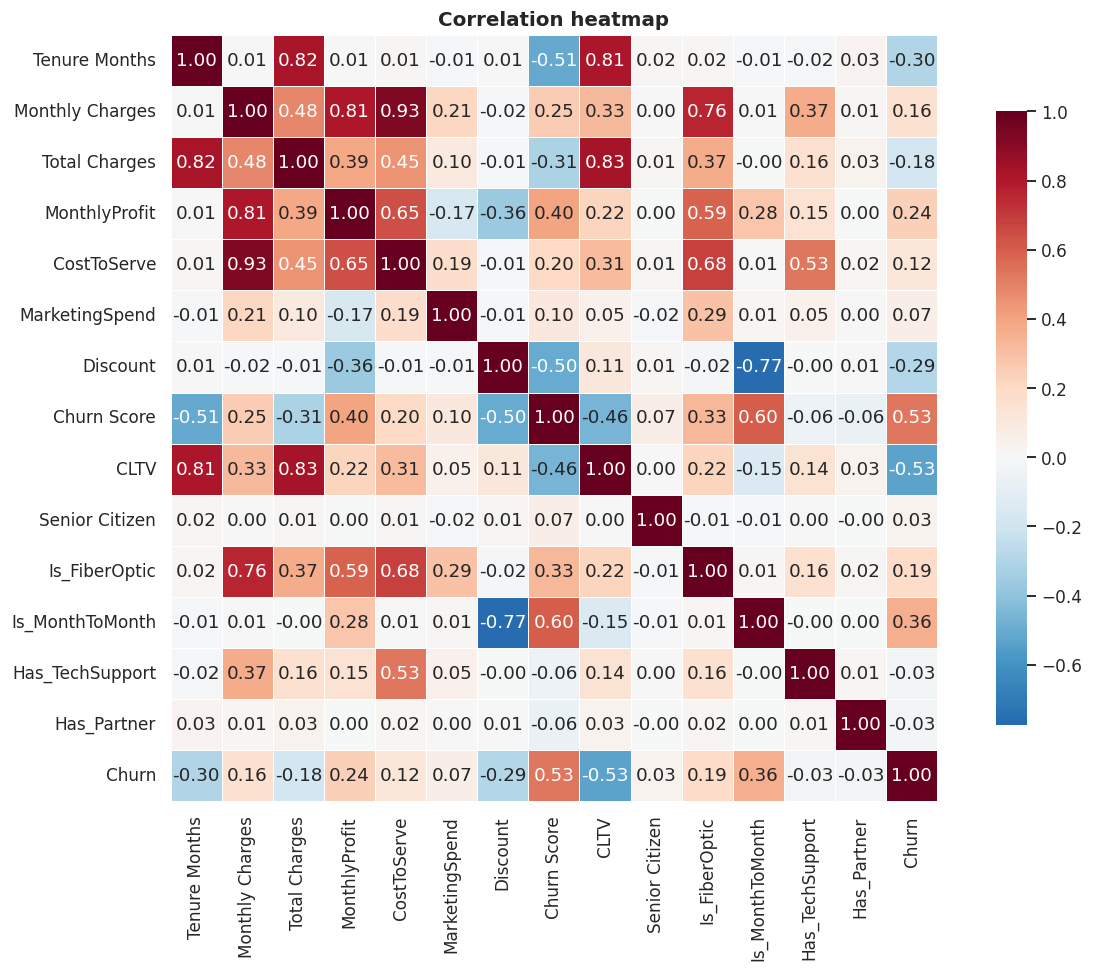

In [12]:
# Encode key categoricals to numeric for a correlation view.
enc = df.copy()
enc["Churn"] = enc["Churn Value"]
enc["Is_FiberOptic"] = (enc["Internet Service"] == "Fiber optic").astype(int)
enc["Is_MonthToMonth"] = (enc["Contract"] == "Month-to-month").astype(int)
enc["Has_TechSupport"] = (enc["Tech Support"] == "Yes").astype(int)
enc["Has_Partner"] = (enc["Partner"] == "Yes").astype(int)
corr_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "MonthlyProfit",
             "CostToServe", "MarketingSpend", "Discount", "Churn Score", "CLTV",
             "Senior Citizen", "Is_FiberOptic", "Is_MonthToMonth",
             "Has_TechSupport", "Has_Partner", "Churn"]
corr = enc[corr_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation heatmap")
plt.tight_layout(); save_fig(fig, "01_correlation_heatmap"); plt.show()

In [13]:
# Top correlates of churn
churn_corr = corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
print("Strongest churn correlations:\n", churn_corr.round(3).head(8))

Strongest churn correlations:
 CLTV              -0.535
Churn Score        0.532
Is_MonthToMonth    0.362
Tenure Months     -0.300
Discount          -0.294
MonthlyProfit      0.239
Is_FiberOptic      0.194
Total Charges     -0.183
Name: Churn, dtype: float64


## 9. Data dictionary
All 39 fields — 33 from the IBM Telco schema plus 6 financial extensions.

In [14]:
data_dictionary = [
 ("CustomerID", "ID", "Unique customer identifier"),
 ("Count", "int", "Constant 1 (row counter, IBM convention)"),
 ("Country", "cat", "Country — United States"),
 ("State", "cat", "State — California (all customers)"),
 ("City", "cat", "California city of residence"),
 ("Zip Code", "cat", "Postal code"),
 ("Lat Long", "str", "Combined latitude, longitude"),
 ("Latitude", "float", "Latitude"),
 ("Longitude", "float", "Longitude"),
 ("Gender", "cat", "Male / Female"),
 ("Senior Citizen", "bin", "1 if 65+ else 0"),
 ("Partner", "cat", "Has a partner (Yes/No)"),
 ("Dependents", "cat", "Has dependents (Yes/No)"),
 ("Tenure Months", "int", "Months as a customer (0-72)"),
 ("Phone Service", "cat", "Subscribed to phone service"),
 ("Multiple Lines", "cat", "Multiple phone lines"),
 ("Internet Service", "cat", "DSL / Fiber optic / No"),
 ("Online Security", "cat", "Add-on: online security"),
 ("Online Backup", "cat", "Add-on: online backup"),
 ("Device Protection", "cat", "Add-on: device protection"),
 ("Tech Support", "cat", "Add-on: tech support"),
 ("Streaming TV", "cat", "Add-on: streaming TV"),
 ("Streaming Movies", "cat", "Add-on: streaming movies"),
 ("Contract", "cat", "Month-to-month / One year / Two year"),
 ("Paperless Billing", "cat", "Paperless billing enrolled"),
 ("Payment Method", "cat", "Payment instrument"),
 ("Monthly Charges", "float", "Current monthly recurring charge ($)"),
 ("Total Charges", "float", "Lifetime charges to date ($)"),
 ("Churn Label", "cat", "Yes/No churn flag (text)"),
 ("Churn Value", "bin", "1 if churned else 0 (model target)"),
 ("Churn Score", "int", "0-100 propensity-to-churn score"),
 ("CLTV", "int", "IBM lifetime-value score (2000-7000)"),
 ("Churn Reason", "cat", "Stated reason for churn / 'Not Churned'"),
 ("MonthlyProfit", "float", "FIN: monthly profit after discount, cost & marketing"),
 ("CostToServe", "float", "FIN: monthly cost to serve the customer ($)"),
 ("MarketingSpend", "float", "FIN: acquisition / marketing spend ($)"),
 ("Discount", "float", "FIN: fractional discount on monthly charge (0-0.3)"),
 ("Region", "cat", "FIN: North / Central / South California"),
 ("SignupMonth", "date", "FIN: month the customer signed up (YYYY-MM-01)"),
]
dd = pd.DataFrame(data_dictionary, columns=["Field", "Type", "Description"])
dd

,Field,Type,Description
0,CustomerID,ID,Unique customer identifier
1,Count,int,"Constant 1 (row counter, IBM convention)"
2,Country,cat,Country — United States
3,State,cat,State — California (all customers)
4,City,cat,California city of residence
5,Zip Code,cat,Postal code
6,Lat Long,str,"Combined latitude, longitude"
7,Latitude,float,Latitude
8,Longitude,float,Longitude
9,Gender,cat,Male / Female


## 10. Save cleaned dataset

In [15]:
PROC.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROC, index=False)
print(f"Saved cleaned data -> {PROC.relative_to(ROOT)}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns | nulls: {int(df.isna().sum().sum())}")

Saved cleaned data -> data/processed/telco_clean.csv
Final shape: 7,043 rows x 39 columns | nulls: 0


## Key takeaways
- **~30% churn** overall, heavily concentrated in **month-to-month** contracts and
  **fiber-optic** customers paying by **electronic check**.
- **Tenure is the dominant protective factor** — churners have markedly lower median
  tenure than retained customers.
- Monthly revenue and profit are right-skewed; IQR capping removed extreme tails
  without dropping any customers.
- These signals motivate the churn model (NB 03) and the profitability work (NB 04).
